# 1. Library import

In [27]:
import sys
sys.path.insert(0, "volatility-pipeline")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import GARCHModel
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    dm_matrix,
    mcs,
)

# 2. Notebook variables set up

In [28]:
# ── Input data variables ────────────────────────────────────────────────────
TICKER          = "BZ=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2026-05-28"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2023-12-31"
TEST_START  = "2024-01-01"
TEST_END    = FULL_DATA_END

# ── Classical econometric model specifications ───────────────────────────────
# Each tuple: (model_type, error_distribution)
# model_type:  'GARCH' | 'GJR-GARCH' | 'EGARCH' | 'APARCH' | 'FIGARCH'
# dist:        'normal' | 't' | 'ged'
GARCH_SPECS = [
    ("GARCH",     "normal"),
    ("GARCH",     "t"),
    ("GARCH",     "ged"),
    ("GJR-GARCH", "normal"),
    ("GJR-GARCH", "t"),
    ("GJR-GARCH", "ged"),
    ("EGARCH",    "normal"),
    ("EGARCH",    "t"),
    ("EGARCH",    "ged"),
    ("APARCH",    "normal"),
    ("APARCH",    "t"),
    ("APARCH",    "ged"),
    ("FIGARCH",   "normal"),
    ("FIGARCH",   "t"),
    ("FIGARCH",   "ged"),
]

# ── Out-of-sample evaluation ─────────────────────────────────────────────────
N_AHEAD     = 1   # forecast horizon (steps ahead); only 1 is currently supported
REFIT_EVERY = 10  # re-estimate model parameters every N test steps

# ── Statistical tests ────────────────────────────────────────────────────────
TEST_LOSS = "squared"  # loss for DM test & MCS: 'squared' | 'absolute' | 'qlike'
MCS_ALPHA = 0.10       # MCS significance level  (0.10 → 90 % MCS)
DM_ALPHA  = 0.05       # Diebold-Mariano rejection threshold

# 3. Import data

In [29]:
# Import data from Yahoo Finance
data = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close = data["Close"].squeeze()
returns = np.log(close / close.shift(1)).dropna()
returns.index = pd.PeriodIndex(returns.index, freq='D')

[*********************100%***********************]  1 of 1 completed


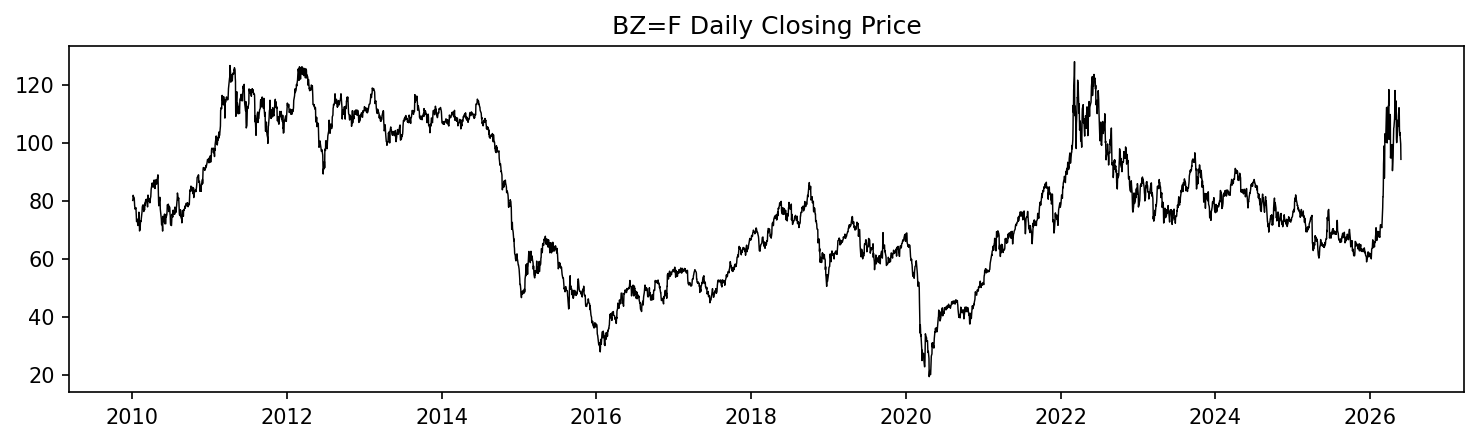

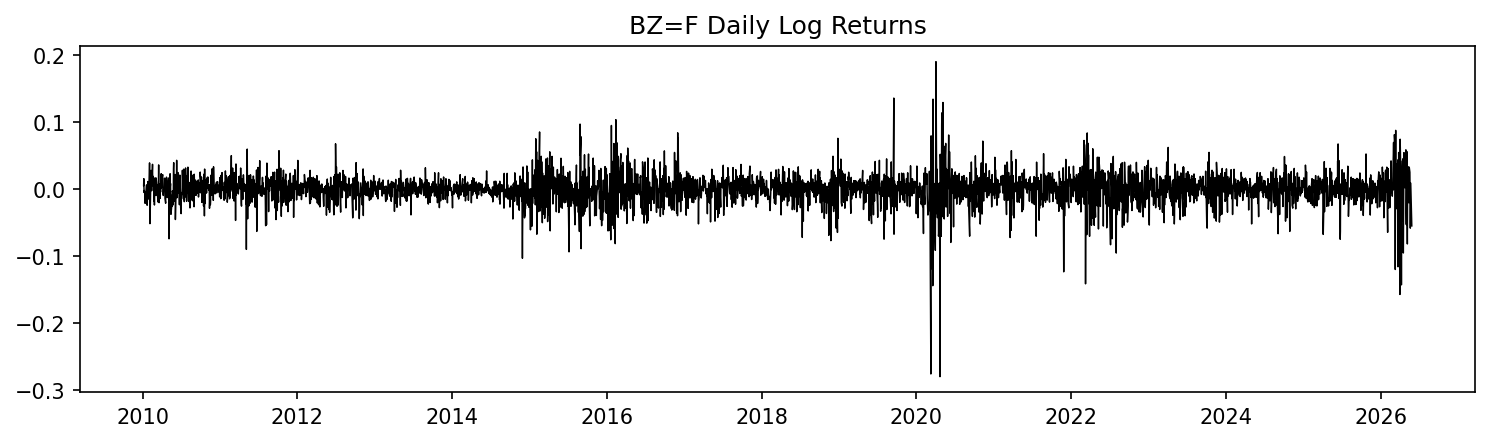

In [30]:
# Visualize the data
plt.figure(figsize=(12, 3), dpi=150)
plt.plot(close, linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Closing Price")
plt.show()

plt.figure(figsize=(12, 3), dpi=150)
plt.plot(returns.index.to_timestamp(), returns.values, label='Daily Returns', linewidth=0.7, color='black')
plt.title(f"{TICKER} Daily Log Returns")
plt.show()

In [31]:
def get_stats_and_ks(series, name):
    stats = series.describe()
    ks_stat, ks_pval = kstest(series, 'norm', args=(series.mean(), series.std()))
    result = {
        'count': stats['count'],
        'mean': stats['mean'],
        'std': stats['std'],
        'min': stats['min'],
        'max': stats['max'],
        'range': stats['max'] - stats['min'],
        'skewness': skew(series),
        'kurtosis': kurtosis(series),
        'KS_stat': ks_stat,
        'KS_pval': ks_pval,
        'Name': name
    }
    return result

stats_list = [
    get_stats_and_ks(returns, "Full Returns")
]

stats_df = pd.DataFrame(stats_list).set_index('Name')
stats_df


,count,mean,std,min,max,range,skewness,kurtosis,KS_stat,KS_pval
Name,,,,,,,,,,
Full Returns,4092.0,0.00004,0.023238,-0.279761,0.190774,0.470536,-0.998553,15.338745,0.086848,2.653574e-27


# 4. Classical Econometric Models (GARCH Family)

Five volatility specifications are estimated with three error distributions each (Normal, Student-t, GED), giving 15 models in total.

| Spec | Description |
|------|-------------|
| GARCH | Standard symmetric GARCH(1,1) — Bollerslev (1986) |
| GJR-GARCH | Asymmetric leverage effect via indicator term — Glosten et al. (1993) |
| EGARCH | Log-variance equation, asymmetric — Nelson (1991) |
| APARCH | Asymmetric power ARCH — Ding et al. (1993) |
| FIGARCH | Fractionally integrated long-memory variance — Baillie et al. (1996) |

## 4.1 In-sample fit

In [32]:
# Split returns into train / test using the date variables set above
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[returns.index >= TEST_START]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")

Train: 2010-01-05  →  2023-12-29  (3488 obs)
Test:  2024-01-02  →  2026-05-27  (604 obs)


In [ ]:
# Fit every model on training data and collect information criteria
insample_models: dict[str, GARCHModel] = {}
ic_rows = []

for model_type, dist in GARCH_SPECS:
    name = f"{model_type}-{dist.upper()}" 
    model = GARCHModel(model_type, dist)
    try:
        model.fit(train_returns)
        insample_models[name] = model
        row = model.info_criteria()
        row["Model"] = name
        ic_rows.append(row)
    except Exception as exc:
        print(f"  [WARNING] {name} failed in-sample fit: {exc}")

ic_df = (
    pd.DataFrame(ic_rows)
    .set_index("Model")
    .sort_values("BIC")
    [["LogL", "AIC", "BIC"]]
)
print(f"Fitted {len(insample_models)} / {len(GARCH_SPECS)} models")
ic_df

Fitted 15 / 15 models


,LogL,AIC,BIC
Model,,,
GJR-GARCH-T,-7098.761765,14209.523529,14246.466032
EGARCH-T,-7105.656926,14221.313852,14252.099270
GARCH-T,-7106.201022,14222.402045,14253.187464
APARCH-T,-7104.776858,14221.553717,14258.496219
FIGARCH-T,-7104.911327,14221.822655,14258.765157
GJR-GARCH-GED,-7113.897074,14239.794147,14276.736650
EGARCH-GED,-7122.009552,14254.019104,14284.804523
GARCH-GED,-7122.232870,14254.465741,14285.251160
APARCH-GED,-7120.798835,14253.597670,14290.540173


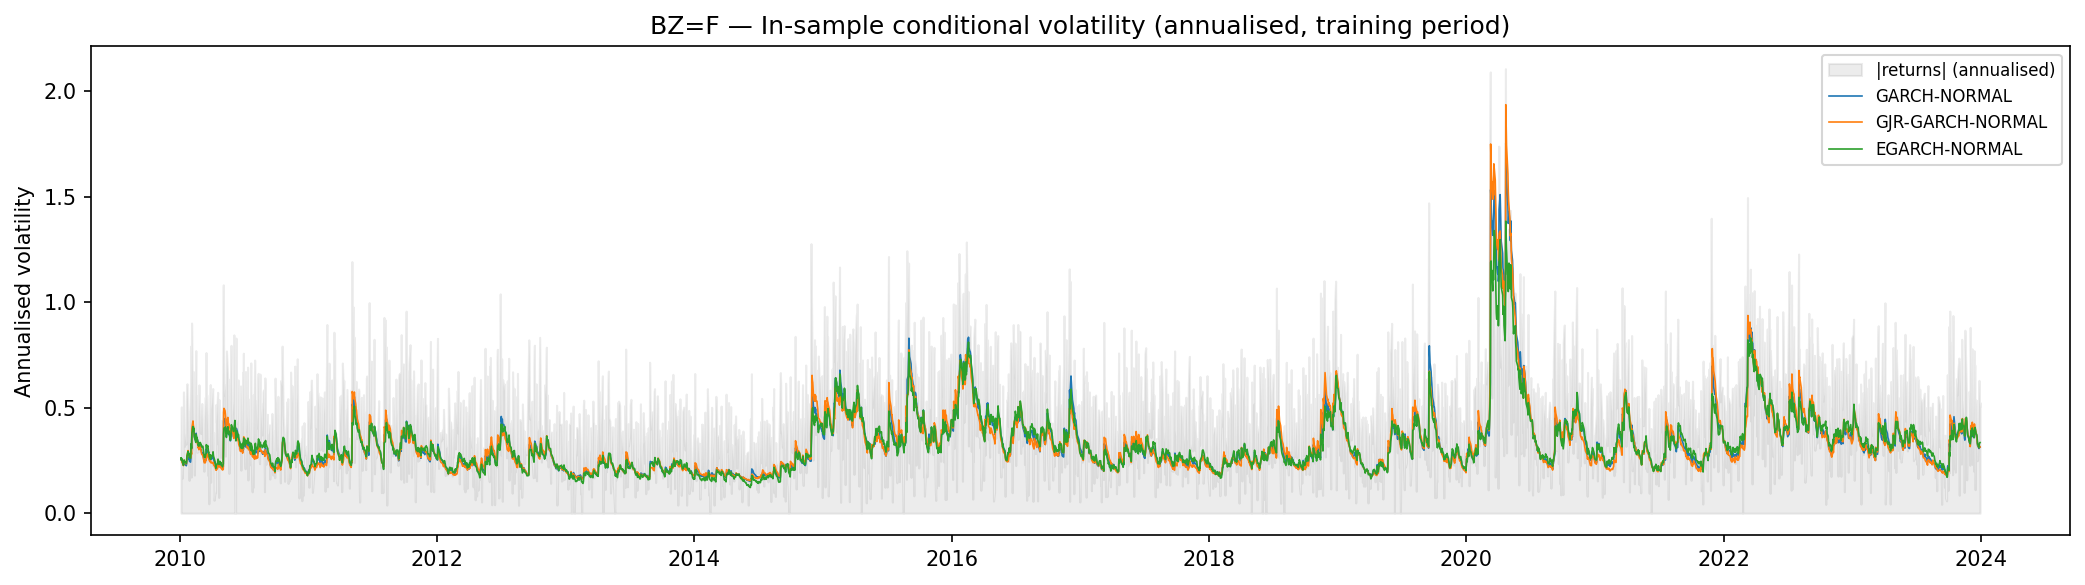

In [34]:
# In-sample conditional volatility — symmetric vs asymmetric comparison
# Shows annualised conditional standard deviation: sqrt(σ²_t × 252)
PLOT_MODELS = ["GARCH-NORMAL", "GJR-GARCH-NORMAL", "EGARCH-NORMAL"]

fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
ax.fill_between(
    train_returns.index.to_timestamp(),
    np.sqrt(np.abs(train_returns.values) * np.sqrt(252)),
    alpha=0.15, color="gray", label="|returns| (annualised)",
)
for name in PLOT_MODELS:
    if name in insample_models:
        cv = insample_models[name].insample_variance()
        ax.plot(
            cv.index.to_timestamp(),
            np.sqrt(cv.values * 252),
            linewidth=0.8,
            label=name,
        )
ax.set_title(f"{TICKER} — In-sample conditional volatility (annualised, training period)")
ax.set_ylabel("Annualised volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4.2 Out-of-sample evaluation

Recursive one-step-ahead forecasting: at each step *t* the model is conditioned on all returns up to *t* and produces a forecast for *t+1*. Parameters are re-estimated every `REFIT_EVERY` steps (expanding window). The realized variance proxy is the squared log-return.

In [35]:
evaluator = RollingEvaluator(n_ahead=N_AHEAD, refit_every=REFIT_EVERY)

# Build (factory, name) pairs — default capture avoids late-binding closure issues
garch_eval_specs = [
    (lambda t=t, d=d: GARCHModel(t, d), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs, train_returns, test_returns, verbose=True
)
print(f"\nCompleted {len(garch_results)} models.")

Evaluating GARCH-NORMAL...
  [GARCH-NORMAL] re-fitted at step 0/604
  [GARCH-NORMAL] re-fitted at step 10/604
  [GARCH-NORMAL] re-fitted at step 20/604
  [GARCH-NORMAL] re-fitted at step 30/604
  [GARCH-NORMAL] re-fitted at step 40/604
  [GARCH-NORMAL] re-fitted at step 50/604
  [GARCH-NORMAL] re-fitted at step 60/604
  [GARCH-NORMAL] re-fitted at step 70/604
  [GARCH-NORMAL] re-fitted at step 80/604
  [GARCH-NORMAL] re-fitted at step 90/604
  [GARCH-NORMAL] re-fitted at step 100/604
  [GARCH-NORMAL] re-fitted at step 110/604
  [GARCH-NORMAL] re-fitted at step 120/604
  [GARCH-NORMAL] re-fitted at step 130/604
  [GARCH-NORMAL] re-fitted at step 140/604
  [GARCH-NORMAL] re-fitted at step 150/604
  [GARCH-NORMAL] re-fitted at step 160/604
  [GARCH-NORMAL] re-fitted at step 170/604
  [GARCH-NORMAL] re-fitted at step 180/604
  [GARCH-NORMAL] re-fitted at step 190/604
  [GARCH-NORMAL] re-fitted at step 200/604
  [GARCH-NORMAL] re-fitted at step 210/604
  [GARCH-NORMAL] re-fitted at step 220

In [36]:
# Out-of-sample metrics table — ranked by RMSE
metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
metrics_df

,RMSE,MAE,MSE,QLIKE
EGARCH-NORMAL,0.001668,0.000633,0.000003,-6.712833
EGARCH-GED,0.001669,0.000623,0.000003,-6.715820
EGARCH-T,0.001671,0.000629,0.000003,-6.719220
APARCH-GED,0.001685,0.000639,0.000003,-6.701345
APARCH-T,0.001686,0.000640,0.000003,-6.704328
APARCH-NORMAL,0.001691,0.000653,0.000003,-6.697591
GARCH-GED,0.001693,0.000647,0.000003,-6.691738
GARCH-T,0.001696,0.000652,0.000003,-6.696458
GARCH-NORMAL,0.001698,0.000658,0.000003,-6.689360
FIGARCH-T,0.001703,0.000646,0.000003,-6.672138


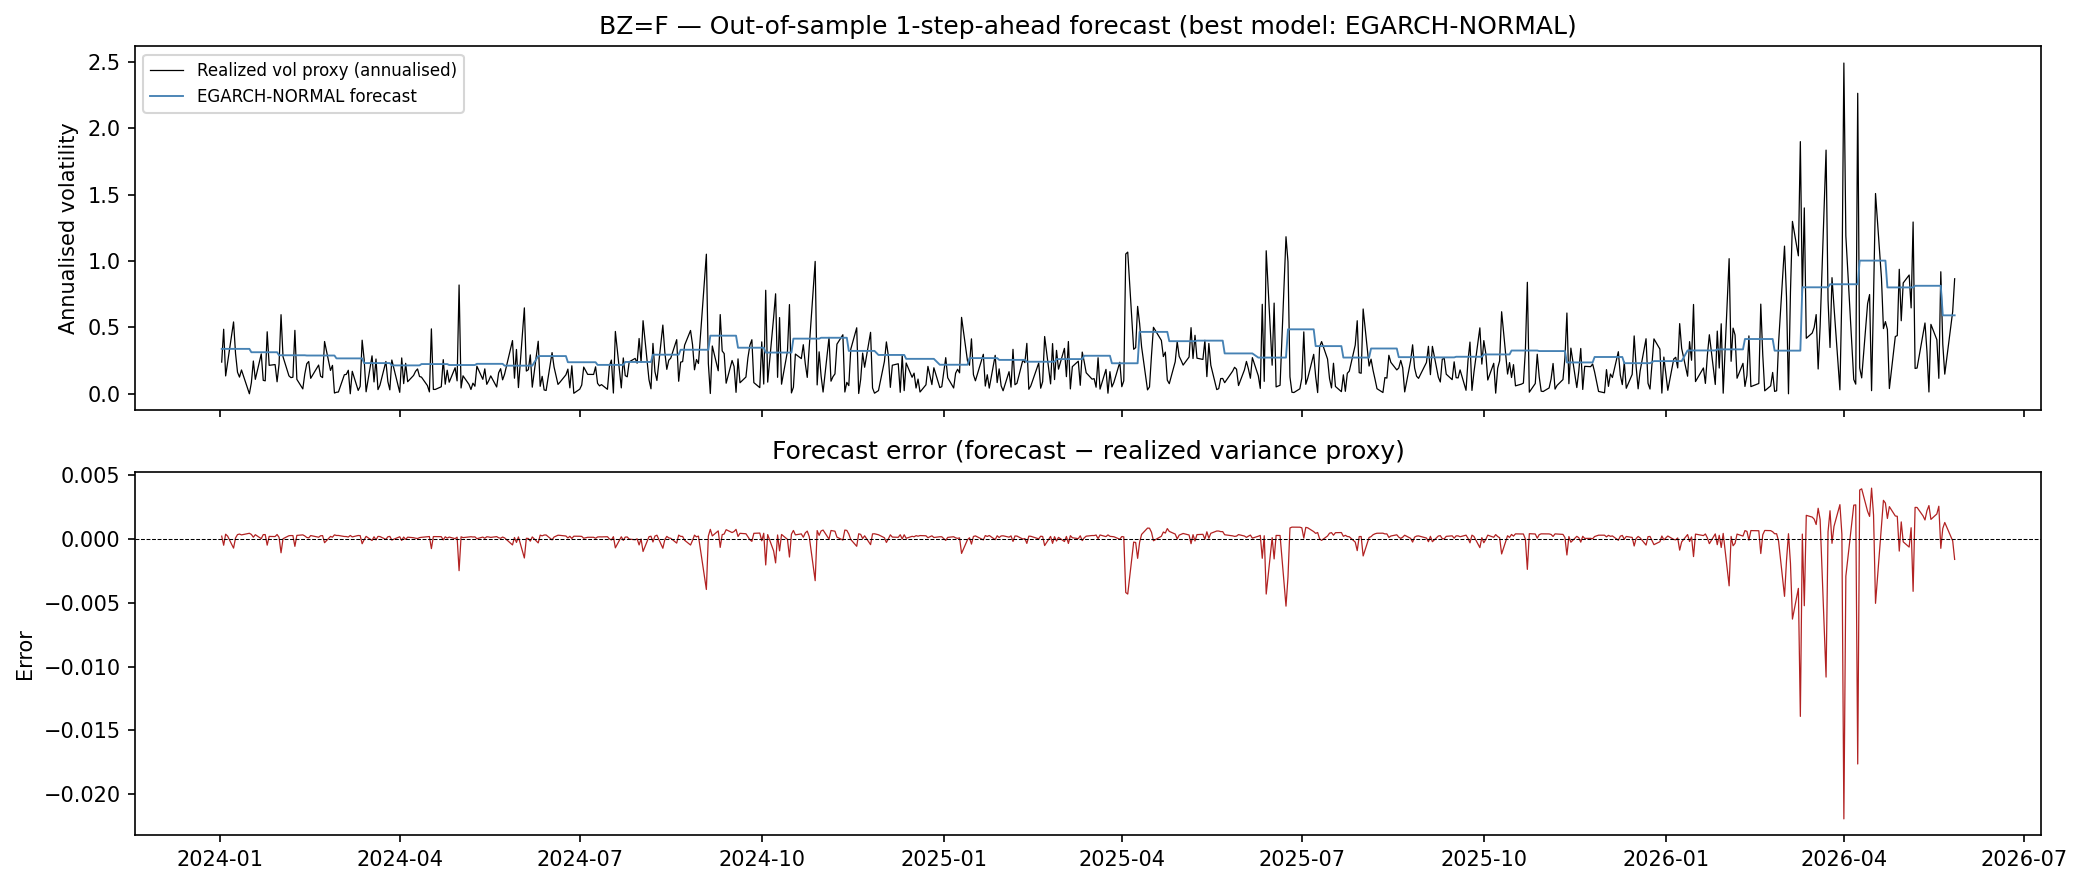

In [37]:
# Forecast vs realized — best model by RMSE
best_name = metrics_df.index[0]
r = garch_results[best_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)

ax0, ax1 = axes
ax0.plot(
    r.actuals.index.to_timestamp(),
    np.sqrt(r.actuals.values * 252),
    color="black", linewidth=0.6, label="Realized vol proxy (annualised)",
)
ax0.plot(
    r.forecasts.index.to_timestamp(),
    np.sqrt(r.forecasts.values * 252),
    color="steelblue", linewidth=0.9, label=f"{best_name} forecast",
)
ax0.set_title(f"{TICKER} — Out-of-sample 1-step-ahead forecast (best model: {best_name})")
ax0.set_ylabel("Annualised volatility")
ax0.legend(fontsize=8)

ax1.plot(
    r.errors.index.to_timestamp(),
    r.errors.values,
    color="firebrick", linewidth=0.6,
)
ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax1.set_title("Forecast error (forecast − realized variance proxy)")
ax1.set_ylabel("Error")

plt.tight_layout()
plt.show()

# 5. Statistical Tests

## 5.1 Diebold-Mariano Test (HLN correction)

Pairwise test of equal predictive accuracy (Harvey, Leybourne & Newbold 1997).  
H₀: models *i* and *j* have equal expected loss.  
Negative MDM statistic → row model has lower loss than column model.  
p-values are two-sided from a *t*(T−1) distribution.

In [38]:
dm_stat_df, dm_pval_df = dm_matrix(garch_results, h=N_AHEAD, loss=TEST_LOSS)

print("MDM statistics (upper triangle):")
dm_stat_df.round(3)

MDM statistics (upper triangle):


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,NaN,0.412,0.882,-3.381,-1.871,-1.737,1.439,1.152,1.186,1.723,1.027,1.198,-2.118,-0.345,-0.888
GARCH-T,NaN,NaN,1.877,-2.631,-3.519,-3.213,1.704,1.348,1.368,1.460,1.564,1.894,-1.838,-0.598,-1.082
GARCH-GED,NaN,NaN,NaN,-2.762,-3.605,-3.511,1.601,1.226,1.262,0.655,1.170,1.544,-2.115,-0.943,-1.418
GJR-GARCH-NORMAL,NaN,NaN,NaN,NaN,1.075,1.431,2.133,1.882,1.878,3.028,2.313,2.439,-0.061,1.301,0.860
GJR-GARCH-T,NaN,NaN,NaN,NaN,NaN,1.858,2.466,2.164,2.132,2.932,3.191,3.306,-0.665,0.954,0.307
GJR-GARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,2.346,2.029,2.012,2.828,2.924,3.082,-0.885,0.807,0.129
EGARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.706,-0.146,-1.340,-1.739,-1.590,-2.201,-2.185,-2.239
EGARCH-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.133,-1.005,-1.236,-1.095,-1.885,-1.734,-1.842
EGARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.051,-1.274,-1.149,-1.927,-1.824,-1.921
APARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.570,0.800,-2.313,-1.003,-1.467


In [39]:
print("DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA")
dm_pval_df.round(4).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold"
    if (not pd.isna(v) and v < DM_ALPHA)
    else "",
)

DM p-values (upper triangle) — highlighted cells: p < DM_ALPHA


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED
GARCH-NORMAL,nan,0.680300,0.378200,0.000800,0.061800,0.083000,0.150800,0.249900,0.236100,0.085300,0.304900,0.231300,0.034600,0.730600,0.374900
GARCH-T,nan,nan,0.061000,0.008700,0.000500,0.001400,0.089000,0.178000,0.172000,0.144700,0.118200,0.058700,0.066500,0.550400,0.279600
GARCH-GED,nan,nan,nan,0.005900,0.000300,0.000500,0.110000,0.220600,0.207400,0.512500,0.242400,0.123200,0.034800,0.345900,0.156800
GJR-GARCH-NORMAL,nan,nan,nan,nan,0.282900,0.153100,0.033400,0.060300,0.060900,0.002600,0.021100,0.015000,0.951200,0.193900,0.390400
GJR-GARCH-T,nan,nan,nan,nan,nan,0.063600,0.013900,0.030900,0.033400,0.003500,0.001500,0.001000,0.506300,0.340500,0.759100
GJR-GARCH-GED,nan,nan,nan,nan,nan,nan,0.019300,0.042900,0.044600,0.004800,0.003600,0.002200,0.376400,0.419700,0.897800
EGARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,0.480600,0.884100,0.180900,0.082500,0.112200,0.028100,0.029300,0.025500
EGARCH-T,nan,nan,nan,nan,nan,nan,nan,nan,0.257500,0.315500,0.216800,0.274100,0.059800,0.083400,0.066000
EGARCH-GED,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.293600,0.203300,0.251100,0.054500,0.068600,0.055200
APARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.569100,0.423900,0.021100,0.316200,0.142800


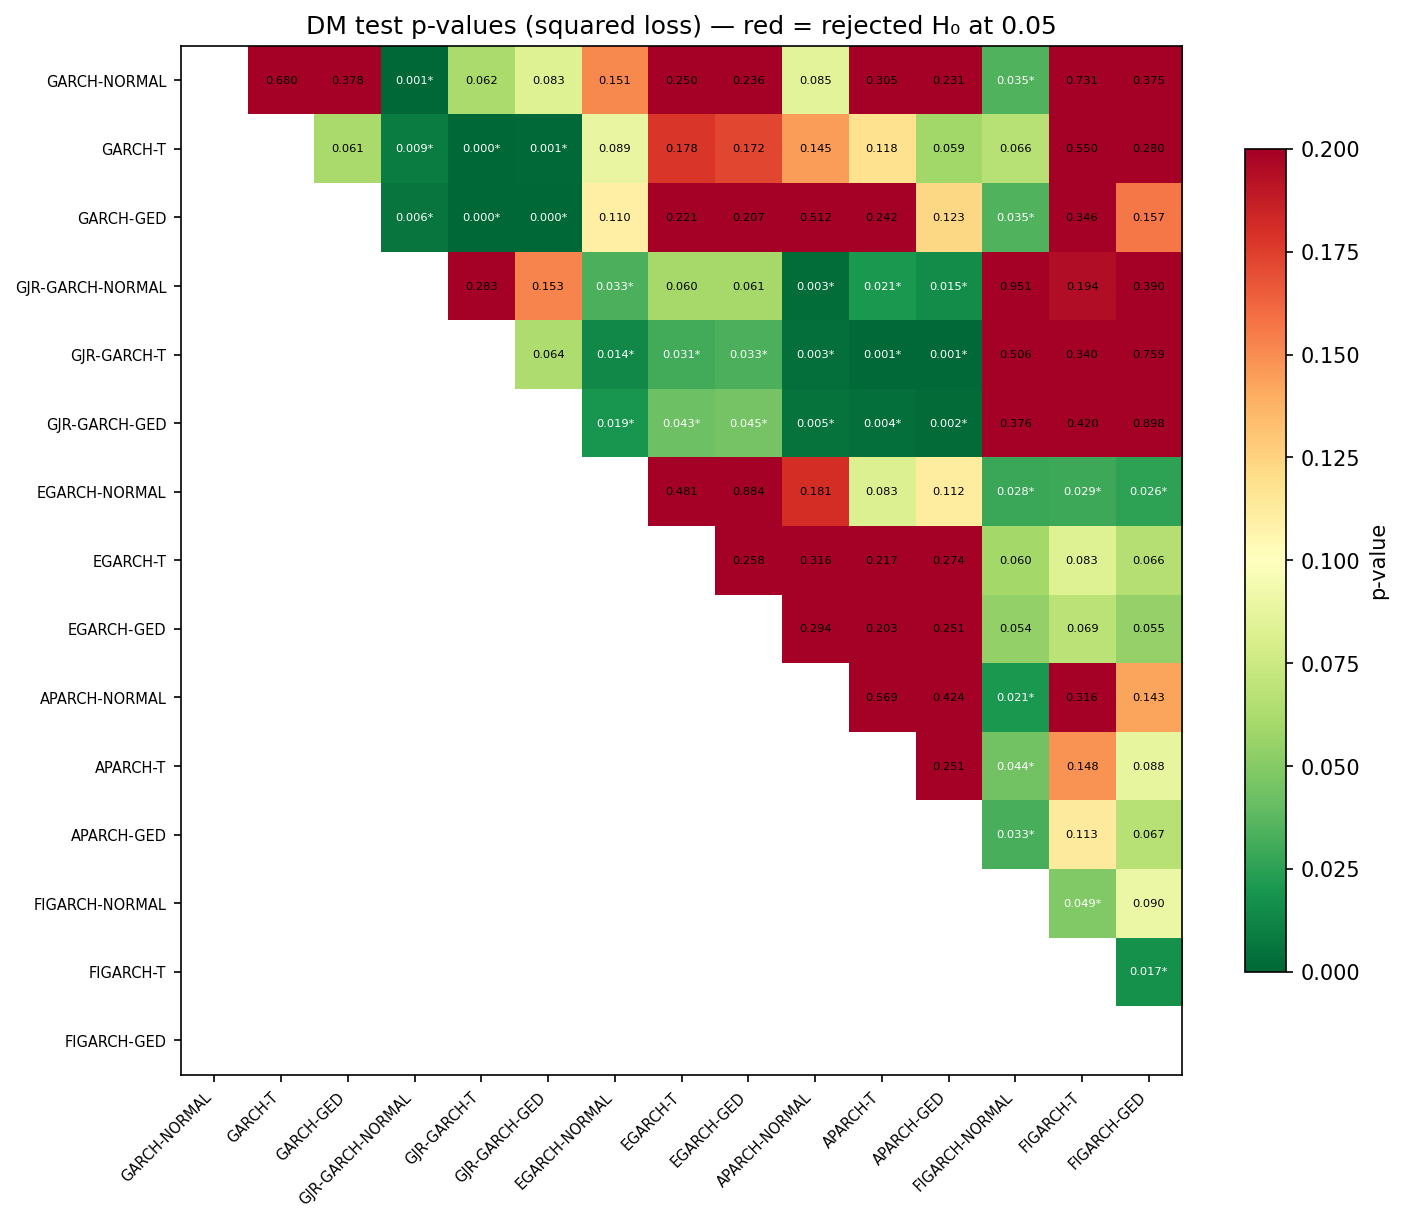

In [40]:
# DM p-value heatmap (upper triangle only)
names  = list(garch_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)

# Mask lower triangle + diagonal (show upper triangle only)
mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)

fig, ax = plt.subplots(figsize=(max(8, n_mods * 0.65), max(6, n_mods * 0.55)), dpi=150)
im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)

ax.set_xticks(range(n_mods))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_mods))
ax.set_yticklabels(names, fontsize=7)
ax.set_title(f"DM test p-values ({TEST_LOSS} loss) — red = rejected H₀ at {DM_ALPHA}")

for i in range(n_mods):
    for j in range(i + 1, n_mods):
        v = pvals[i, j]
        if not np.isnan(v):
            sig = "*" if v < DM_ALPHA else ""
            ax.text(j, i, f"{v:.3f}{sig}", ha="center", va="center", fontsize=5.5,
                    color="white" if v < 0.05 else "black")

plt.tight_layout()
plt.show()

## 5.2 Model Confidence Set (MCS)

Hansen, Lunde & Nason (2011). Sequential elimination of the worst model using the T_max statistic until the null of equal predictive accuracy cannot be rejected. Inference via stationary bootstrap (Politis & Romano 1994).

Models with `mcs_pvalue > MCS_ALPHA` belong to the (1 − MCS_ALPHA) MCS.

In [41]:
mcs_result = mcs(
    garch_results,
    loss=TEST_LOSS,
    alpha=MCS_ALPHA,
    n_boot=2000,
    seed=42,
)
print(mcs_result)
print()
mcs_result.summary().style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["in_mcs"],
).format({"mcs_pvalue": "{:.4f}"})

MCSResult(alpha=0.1, loss='squared', n_included=15, models=['GARCH-NORMAL', 'GARCH-T', 'GARCH-GED', 'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED', 'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED', 'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED', 'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED'])



,mcs_pvalue,in_mcs
GARCH-NORMAL,1.0000,True
GARCH-T,1.0000,True
GARCH-GED,1.0000,True
GJR-GARCH-NORMAL,1.0000,True
GJR-GARCH-T,1.0000,True
GJR-GARCH-GED,1.0000,True
EGARCH-NORMAL,1.0000,True
EGARCH-T,1.0000,True
EGARCH-GED,1.0000,True
APARCH-NORMAL,1.0000,True
